In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier , GradientBoostingClassifier , AdaBoostClassifier , BaggingClassifier , ExtraTreesClassifier, VotingClassifier , StackingClassifier, HistGradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.ensemble import RUSBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
from sklearn.preprocessing import label_binarize
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,precision_score, recall_score,f1_score,precision_score,recall_score,roc_auc_score,roc_curve
from sklearn.metrics import f1_score
import warnings
warnings.filterwarnings("ignore")

## **Dataset Load**

In [2]:
df = pd.read_csv("Student_performance_data _.csv")

## See the first 5 rows

In [3]:
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


## See the last 5 rows

In [4]:
df.tail()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
2387,3388,18,1,0,3,10.680555,2,0,4,1,0,0,0,3.455509,0.0
2388,3389,17,0,0,1,7.583217,4,1,4,0,1,0,0,3.279150,4.0
2389,3390,16,1,0,2,6.805500,20,0,2,0,0,0,1,1.142333,2.0
2390,3391,16,1,1,0,12.416653,17,0,2,0,1,1,0,1.803297,1.0
2391,3392,16,1,0,2,17.819907,13,0,2,0,0,0,1,2.140014,1.0


## Dataset Shape

In [5]:
df.shape

(2392, 15)

## Dataset Columns

In [6]:
df.columns

Index(['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation',
       'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport',
       'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA',
       'GradeClass'],
      dtype='object')

## Dataset Info

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB


## Statistical Analysis

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
StudentID,2392.0,2196.500000,690.655244,1001.000000,1598.750000,2196.500000,2794.250000,3392.000000
Age,2392.0,16.468645,1.123798,15.000000,15.000000,16.000000,17.000000,18.000000
Gender,2392.0,0.510870,0.499986,0.000000,0.000000,1.000000,1.000000,1.000000
Ethnicity,2392.0,0.877508,1.028476,0.000000,0.000000,0.000000,2.000000,3.000000
ParentalEducation,2392.0,1.746237,1.000411,0.000000,1.000000,2.000000,2.000000,4.000000
StudyTimeWeekly,2392.0,9.771992,5.652774,0.001057,5.043079,9.705363,14.408410,19.978094
Absences,2392.0,14.541388,8.467417,0.000000,7.000000,15.000000,22.000000,29.000000
Tutoring,2392.0,0.301421,0.458971,0.000000,0.000000,0.000000,1.000000,1.000000
ParentalSupport,2392.0,2.122074,1.122813,0.000000,1.000000,2.000000,3.000000,4.000000
Extracurricular,2392.0,0.383361,0.486307,0.000000,0.000000,0.000000,1.000000,1.000000


## Dataset Datatype

In [9]:
df.dtypes

StudentID              int64
Age                    int64
Gender                 int64
Ethnicity              int64
ParentalEducation      int64
StudyTimeWeekly      float64
Absences               int64
Tutoring               int64
ParentalSupport        int64
Extracurricular        int64
Sports                 int64
Music                  int64
Volunteering           int64
GPA                  float64
GradeClass           float64
dtype: object

## EDA 

## Dataset missing value check


In [10]:
df.isnull().sum()

StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64

## Duplicate value check

In [11]:
df.duplicated().sum()

np.int64(0)


## Visualization

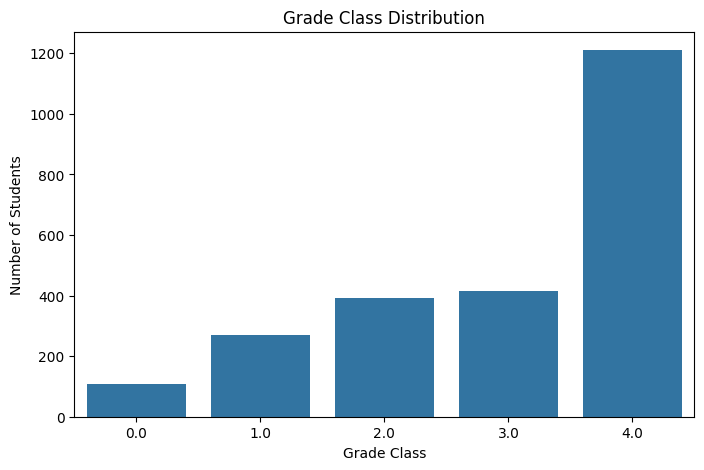

In [12]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='GradeClass')
plt.title('Grade Class Distribution')
plt.xlabel('Grade Class')
plt.ylabel('Number of Students')
plt.show()

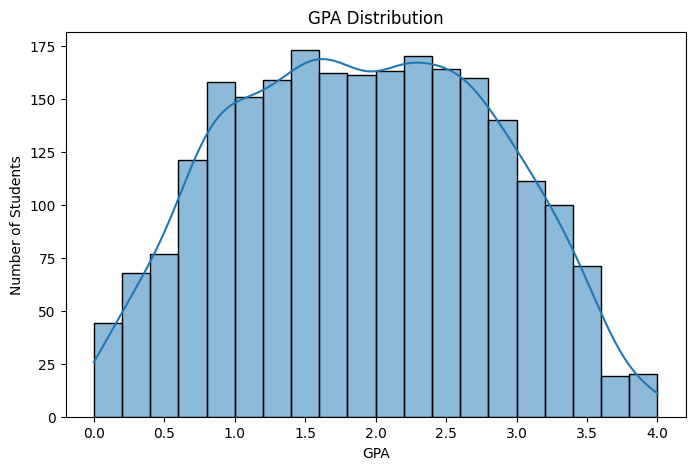

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='GPA', bins=20, kde=True)
plt.title('GPA Distribution')
plt.xlabel('GPA')
plt.ylabel('Number of Students')
plt.show()

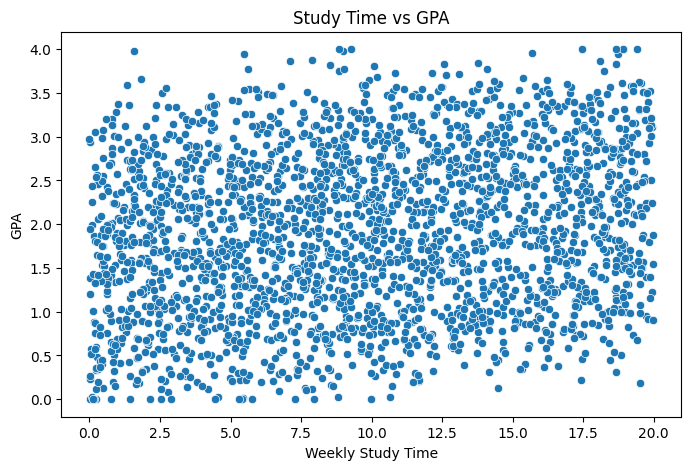

In [14]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='StudyTimeWeekly', y='GPA')
plt.title('Study Time vs GPA')
plt.xlabel('Weekly Study Time')
plt.ylabel('GPA')
plt.show()

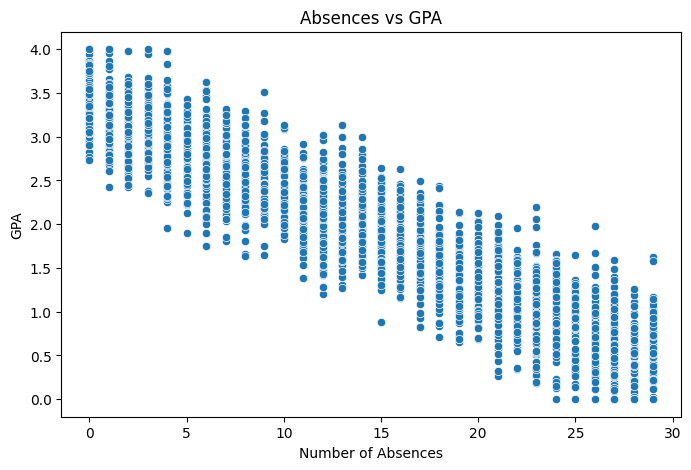

In [15]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Absences', y='GPA')
plt.title('Absences vs GPA')
plt.xlabel('Number of Absences')
plt.ylabel('GPA')
plt.show()

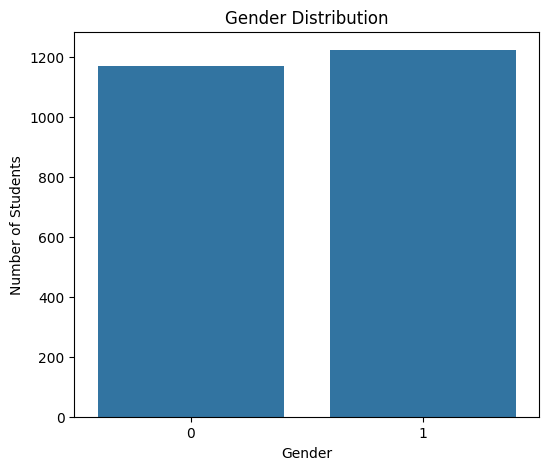

In [16]:
plt.figure(figsize=(6,5))
sns.countplot(data=df, x='Gender')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of Students')
plt.show()

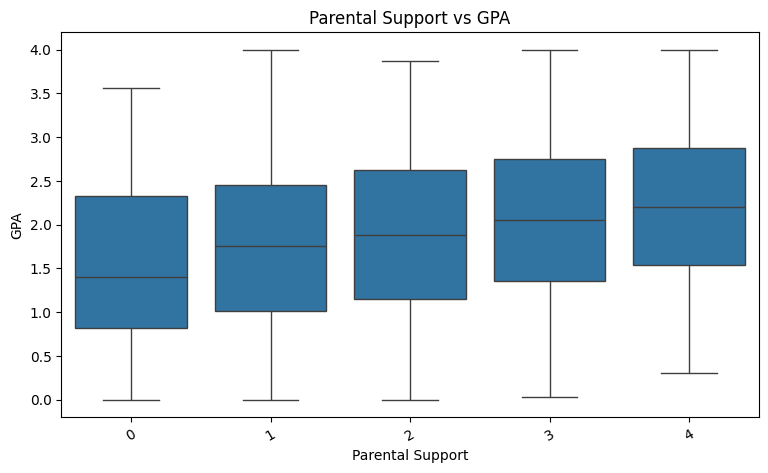

In [17]:
plt.figure(figsize=(9,5))
sns.boxplot(data=df, x='ParentalSupport', y='GPA')
plt.title('Parental Support vs GPA')
plt.xlabel('Parental Support')
plt.ylabel('GPA')
plt.xticks(rotation=30)
plt.show()

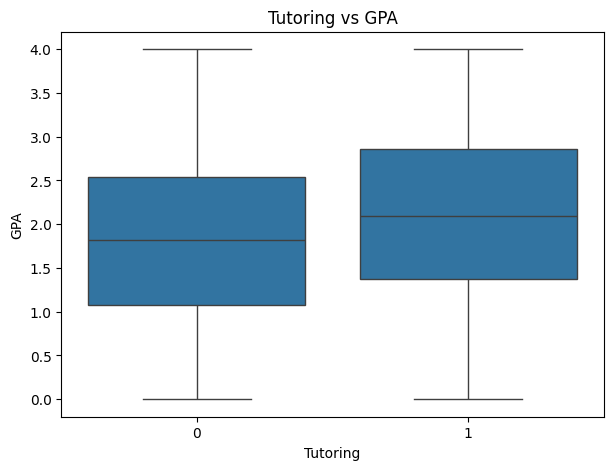

In [18]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Tutoring', y='GPA')
plt.title('Tutoring vs GPA')
plt.xlabel('Tutoring')
plt.ylabel('GPA')
plt.show()

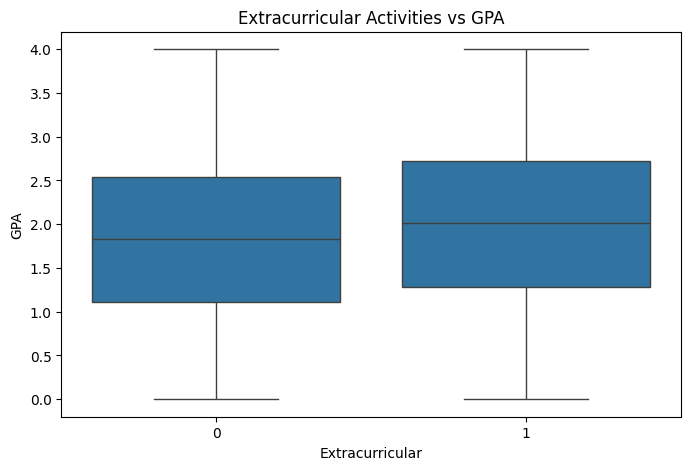

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Extracurricular', y='GPA')
plt.title('Extracurricular Activities vs GPA')
plt.xlabel('Extracurricular')
plt.ylabel('GPA')
plt.show()

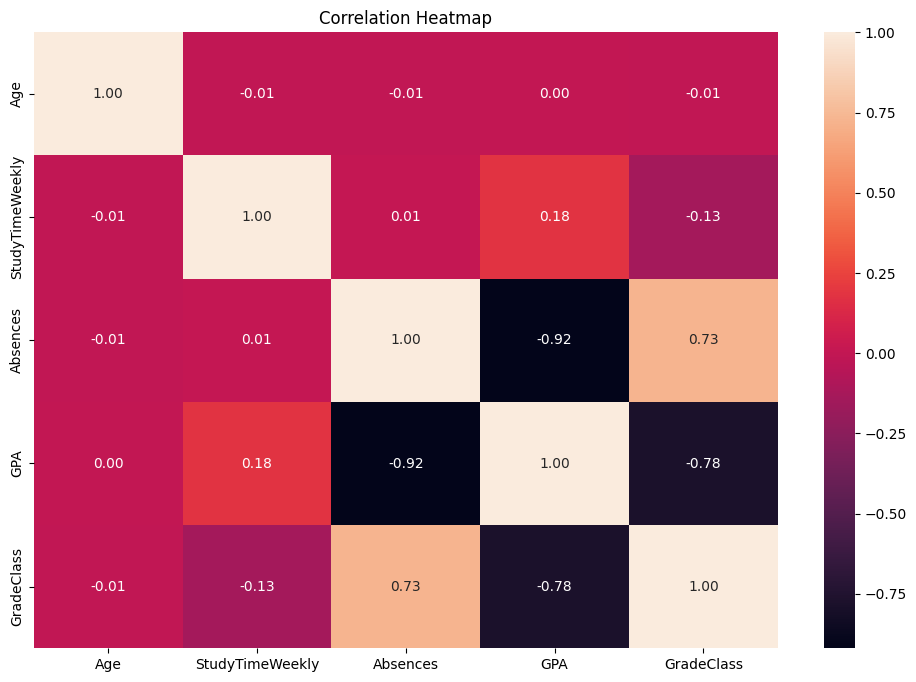

In [20]:
plt.figure(figsize=(12,8))

numeric_cols = [
    'Age',
    'StudyTimeWeekly',
    'Absences',
    'GPA',
    'GradeClass'
]

corr = df[numeric_cols].corr()

sns.heatmap(corr,annot=True,cmap='rocket',fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

In [21]:
x = df.drop(['GradeClass'],axis = 1)
y = df['GradeClass']

In [22]:
xtrain , xtest, ytrain , ytest = train_test_split(x,y, test_size = .75,random_state = 42)

# `Performing Random Forest`

In [23]:
rf = RandomForestClassifier()
rf.fit(xtrain,ytrain)

print("Training Score : ", rf.score(xtrain,ytrain)*100)
print("Testing Score : ", rf.score(xtest,ytest)*100)

# Prediction 

y_pred_rf = rf.predict(xtest)
print("Predict successfully ")


Training Score :  100.0
Testing Score :  91.36008918617614
Predict successfully 


# `Random Forest` Model Evaluation

Accuracy Score for Random Forest  :  91.36008918617614


Random Forest Classifier
              precision    recall  f1-score   support

         0.0       0.81      0.34      0.48        77
         1.0       0.78      0.84      0.81       197
         2.0       0.93      0.91      0.92       295
         3.0       0.88      0.92      0.90       306
         4.0       0.95      0.98      0.96       919

    accuracy                           0.91      1794
   macro avg       0.87      0.80      0.81      1794
weighted avg       0.91      0.91      0.91      1794



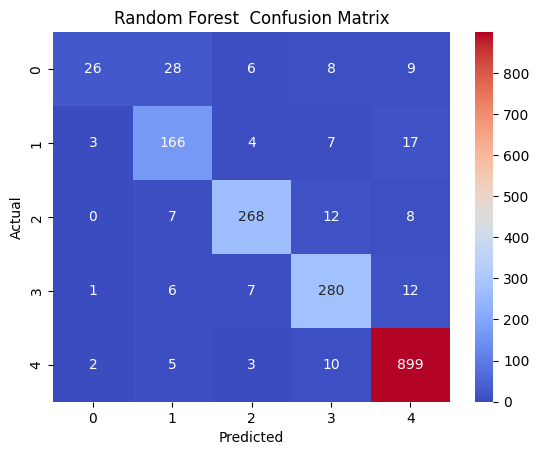

F1 Score for Random Forest :  90.82387092328318
Sensitivity for Random Forest :  91.36008918617614
Specificity for Random Forest :  96.3321385409002
NPV for Random Forest         :  97.85878156789894
FPR for Random Forest         :  3.667861459099798
FNR for Random Forest         :  8.639910813823857
ROC-AUC Score for Random Forest :  0.9865767876728218


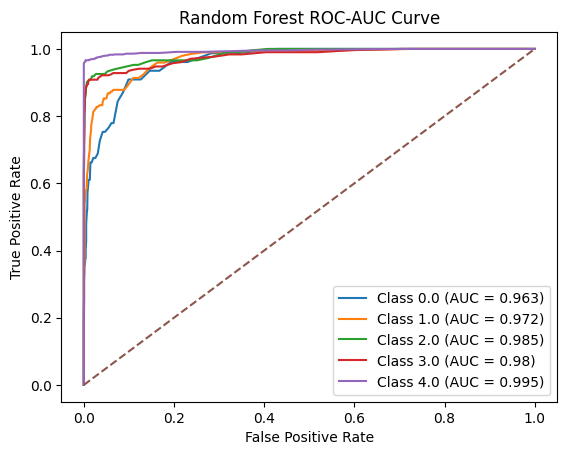

In [24]:
## Accuracy Score 
ac = accuracy_score(ytest , y_pred_rf)
print("Accuracy Score for Random Forest  : ", ac *100)
print('\n')


#classification report
cr = classification_report(ytest,y_pred_rf)
print("Random Forest Classifier")
print(cr)


# Confusion Matrix
cm = confusion_matrix(ytest,y_pred_rf)
sns.heatmap(cm , annot = True  ,cmap='coolwarm', fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest  Confusion Matrix")
plt.show()

#F1 Score
f1_rf = f1_score(ytest, y_pred_rf,average='weighted')
print("F1 Score for Random Forest : ", f1_rf*100)


# Sensitivity
sensitivity_rf = recall_score(ytest,y_pred_rf, average='weighted')
print("Sensitivity for Random Forest : ", sensitivity_rf * 100)

# Classes
classes = np.unique(ytest)

# Specificity, NPV, FPR, FNR

specificity_list = []
npv_list = []
fpr_list = []
fnr_list = []

classes = np.unique(ytest)

for i in range(len(classes)):

    TP = cm[i, i]

    FP = cm[:, i].sum() - TP

    FN = cm[i, :].sum() - TP

    TN = cm.sum() - (TP + FP + FN)

    # Specificity
    specificity = TN / (TN + FP)

    # NPV
    npv = TN / (TN + FN)

    # False Positive Rate
    fpr = FP / (FP + TN)

    # False Negative Rate
    fnr = FN / (FN + TP)

    specificity_list.append(specificity)
    npv_list.append(npv)
    fpr_list.append(fpr)
    fnr_list.append(fnr)


# Weighted Average

weights = cm.sum(axis=1)

specificity_rf = np.average(specificity_list,weights=weights)
npv_rf = np.average(npv_list,weights=weights)
fpr_rf = np.average(fpr_list,weights=weights)
fnr_rf = np.average( fnr_list, weights=weights)


print("Specificity for Random Forest : ", specificity_rf * 100)
print("NPV for Random Forest         : ", npv_rf * 100)
print("FPR for Random Forest         : ", fpr_rf * 100)
print("FNR for Random Forest         : ", fnr_rf * 100)


# ROC-AUC
y_prob_rf = rf.predict_proba(xtest)
roc_auc_rf = roc_auc_score(ytest,y_prob_rf,multi_class='ovr',average='weighted')
print("ROC-AUC Score for Random Forest : ", roc_auc_rf)

# ROC-AUC Curve
from sklearn.preprocessing import label_binarize

ytest_bin = label_binarize(ytest,classes=classes)

plt.figure()

for i in range(len(classes)):

    fpr_curve, tpr_curve, threshold = roc_curve( ytest_bin[:, i], y_prob_rf[:, i])

    auc_class = roc_auc_score( ytest_bin[:, i], y_prob_rf[:, i])

    plt.plot(fpr_curve,tpr_curve,label="Class " + str(classes[i]) + " (AUC = " + str(round(auc_class, 3)) + ")")


plt.plot([0, 1],[0, 1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Random Forest ROC-AUC Curve")

plt.legend()


 # Performing Decision Tree 

In [35]:
dt = DecisionTreeClassifier()
dt.fit(xtrain,ytrain)

print("Training Score : ", dt.score(xtrain,ytrain)*100)
print("Testing Score : ", dt.score(xtest,ytest)*100)

# Prediction 

y_pred_dt = dt.predict(xtest)
print("Predict successfully ")

Training Score :  100.0
Testing Score :  93.08807134894091
Predict successfully 


Accuracy Score :  93.08807134894091


Decision Tree Classifier
              precision    recall  f1-score   support

         0.0       0.72      0.74      0.73        77
         1.0       0.85      0.86      0.86       197
         2.0       0.94      0.93      0.93       295
         3.0       0.91      0.91      0.91       306
         4.0       0.97      0.97      0.97       919

    accuracy                           0.93      1794
   macro avg       0.88      0.88      0.88      1794
weighted avg       0.93      0.93      0.93      1794





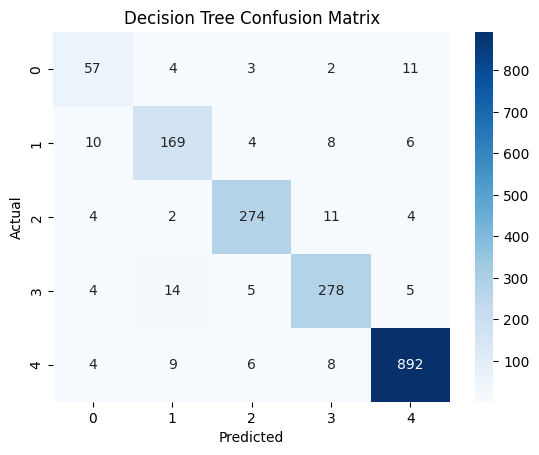

F1 Score For Decision Tree Classifier :  93.10333279534308


Specificity for Random Forest :  97.69356539216987
NPV for Random Forest         :  97.62731998597786
FPR for Random Forest         :  2.306434607830136
FNR for Random Forest         :  6.911928651059086
ROC-AUC Score for Decision Tree :  0.9539081837055539


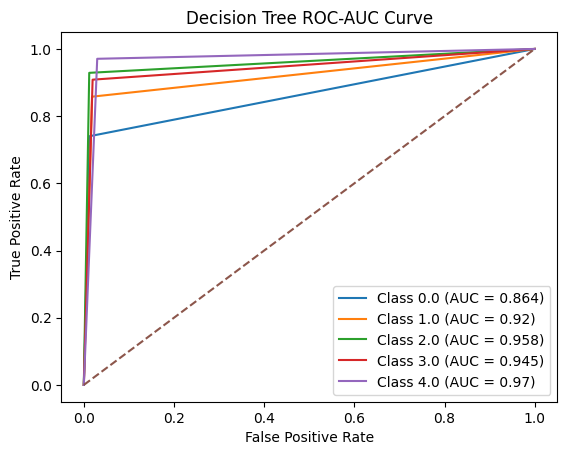

In [36]:
#Accuracy_score 
ac = accuracy_score(ytest , y_pred_dt)
print("Accuracy Score : ", ac *100)
print('\n')

#Classification Report
cr = classification_report(ytest,y_pred_dt)
print("Decision Tree Classifier")
print(cr)
print('\n')


# confusin matrix
cm = confusion_matrix(ytest,y_pred_dt)
sns.heatmap(cm , annot = True , cmap = 'Blues', fmt = 'd')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()



#F1 Score
f1 = f1_score(ytest , y_pred_dt,average='weighted')
print("F1 Score For Decision Tree Classifier : ", f1 *100)
print('\n')


# Classes
classes = np.unique(ytest)

# Specificity, NPV, FPR, FNR


specificity_list = []
npv_list = []
fpr_list = []
fnr_list = []

classes = np.unique(ytest)

for i in range(len(classes)):

    TP = cm[i, i]

    FP = cm[:, i].sum() - TP

    FN = cm[i, :].sum() - TP

    TN = cm.sum() - (TP + FP + FN)

    # Specificity
    specificity = TN / (TN + FP)

    # NPV
    npv = TN / (TN + FN)

    # False Positive Rate
    fpr = FP / (FP + TN)

    # False Negative Rate
    fnr = FN / (FN + TP)

    specificity_list.append(specificity)
    npv_list.append(npv)
    fpr_list.append(fpr)
    fnr_list.append(fnr)


# Weighted Average
weights = cm.sum(axis=1)

specificity_rf = np.average(specificity_list,weights=weights)
npv_rf = np.average(npv_list,weights=weights)
fpr_rf = np.average(fpr_list,weights=weights)
fnr_rf = np.average( fnr_list, weights=weights)


print("Specificity for Random Forest : ", specificity_rf * 100)
print("NPV for Random Forest         : ", npv_rf * 100)
print("FPR for Random Forest         : ", fpr_rf * 100)
print("FNR for Random Forest         : ", fnr_rf * 100)



# ROC-AUC
y_prob_dt = dt.predict_proba(xtest)
roc_auc_dt = roc_auc_score(ytest,y_prob_dt,multi_class='ovr',average='weighted')
print("ROC-AUC Score for Decision Tree : ", roc_auc_dt)


# ROC-AUC Curve


ytest_bin = label_binarize(ytest,classes=classes)

plt.figure()

for i in range(len(classes)):

    fpr_curve, tpr_curve, threshold = roc_curve( ytest_bin[:, i], y_prob_dt[:, i])

    auc_class = roc_auc_score( ytest_bin[:, i], y_prob_dt[:, i])

    plt.plot(fpr_curve,tpr_curve,label="Class " + str(classes[i]) + " (AUC = " + str(round(auc_class, 3)) + ")")


plt.plot([0, 1],[0, 1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Decision Tree ROC-AUC Curve")

plt.legend()

plt.show()


# Performing XGboost Classifier

In [37]:
# XGBoost Model
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

# Training
xgb.fit(xtrain, ytrain)

# Scores
print("Training Score : ", xgb.score(xtrain, ytrain) * 100)
print("Testing Score : ", xgb.score(xtest, ytest) * 100)

# Prediction
y_pred_xgb = xgb.predict(xtest)
print("Predict successfully")

Training Score :  100.0
Testing Score :  91.69453734671126
Predict successfully


Accuracy Score :  91.69453734671126


XGBoost Classifier
              precision    recall  f1-score   support

         0.0       0.68      0.60      0.63        77
         1.0       0.83      0.88      0.86       197
         2.0       0.92      0.93      0.92       295
         3.0       0.87      0.90      0.88       306
         4.0       0.97      0.95      0.96       919

    accuracy                           0.92      1794
   macro avg       0.85      0.85      0.85      1794
weighted avg       0.92      0.92      0.92      1794





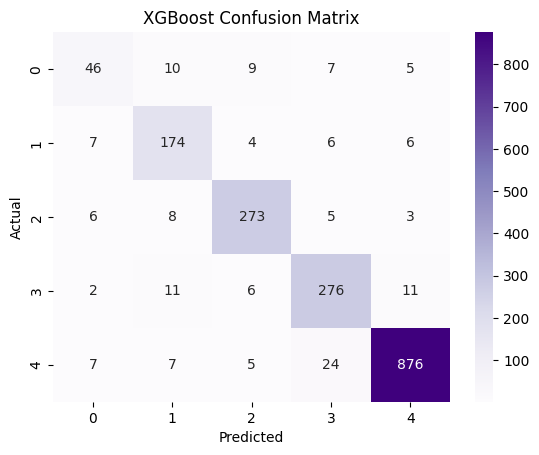

F1 Score For XGBoost Classifier :  91.67955292724639
Specificity for XGBoost :  97.48914049666844
NPV for XGBoost         :  96.70845844943182
FPR for XGBoost         :  2.5108595033315693
FNR for XGBoost         :  8.30546265328874
ROC-AUC Score for XGBoost :  0.9928259894506506


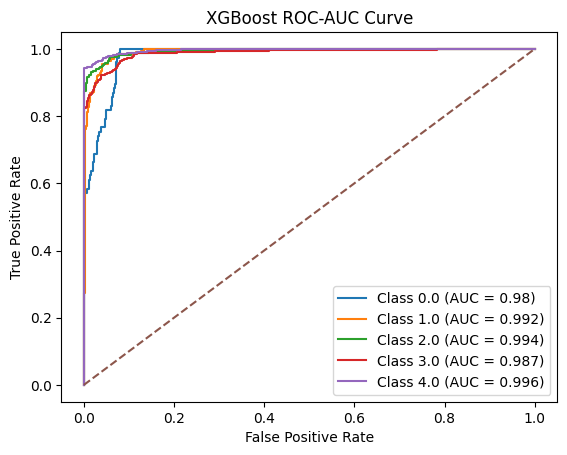

In [43]:
#Accuracy_score 
ac = accuracy_score(ytest , y_pred_xgb)
print("Accuracy Score : ", ac *100)
print('\n')

#Classification Report
cr = classification_report(ytest,y_pred_xgb)
print("XGBoost Classifier")
print(cr)
print('\n')


# confusin matrix
cm = confusion_matrix(ytest,y_pred_xgb)
sns.heatmap(cm , annot = True , cmap = 'Purples', fmt = 'd')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()


#F1 Score
f1 = f1_score(ytest , y_pred_xgb,average='weighted')
print("F1 Score For XGBoost Classifier : ", f1 *100)


# Classes
classes = np.unique(ytest)

# Specificity, NPV, FPR, FNR


specificity_list = []
npv_list = []
fpr_list = []
fnr_list = []

classes = np.unique(ytest)

for i in range(len(classes)):

    TP = cm[i, i]

    FP = cm[:, i].sum() - TP

    FN = cm[i, :].sum() - TP

    TN = cm.sum() - (TP + FP + FN)

    # Specificity
    specificity = TN / (TN + FP)

    # NPV
    npv = TN / (TN + FN)

    # False Positive Rate
    fpr = FP / (FP + TN)

    # False Negative Rate
    fnr = FN / (FN + TP)

    specificity_list.append(specificity)
    npv_list.append(npv)
    fpr_list.append(fpr)
    fnr_list.append(fnr)


# Weighted Average
weights = cm.sum(axis=1)

specificity_xgb = np.average(specificity_list,weights=weights)
npv_xgb = np.average(npv_list,weights=weights)
fpr_xgb = np.average(fpr_list,weights=weights)
fnr_xgb = np.average( fnr_list, weights=weights)


print("Specificity for XGBoost : ", specificity_xgb * 100)
print("NPV for XGBoost         : ", npv_xgb * 100)
print("FPR for XGBoost         : ", fpr_xgb * 100)
print("FNR for XGBoost         : ", fnr_xgb * 100)



# ROC-AUC
y_prob_xgb = xgb.predict_proba(xtest)
roc_auc_xgb = roc_auc_score(ytest,y_prob_xgb,multi_class='ovr',average='weighted')
print("ROC-AUC Score for XGBoost : ", roc_auc_xgb)


# ROC-AUC Curve


ytest_bin = label_binarize(ytest,classes=classes)

plt.figure()

for i in range(len(classes)):

    fpr_curve, tpr_curve, threshold = roc_curve( ytest_bin[:, i], y_prob_xgb[:, i])

    auc_class = roc_auc_score( ytest_bin[:, i], y_prob_xgb[:, i])

    plt.plot(fpr_curve,tpr_curve,label="Class " + str(classes[i]) + " (AUC = " + str(round(auc_class, 3)) + ")")


plt.plot([0, 1],[0, 1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("XGBoost ROC-AUC Curve")

plt.legend()

plt.show()


# `Performing SVM classifier`

In [47]:
svm = SVC(kernel='linear',probability=True, random_state=42)


# Training
svm.fit(xtrain, ytrain) 
print("Training Score : ", svm.score(xtrain, ytrain) * 100)

print("Testing Score : ", svm.score(xtest, ytest) * 100)

# Prediction
y_pred_svm = svm.predict(xtest)


Training Score :  80.93645484949833
Testing Score :  79.15273132664437


Accuracy Score :  79.15273132664437
              precision    recall  f1-score   support

         0.0       0.20      0.18      0.19        77
         1.0       0.61      0.65      0.63       197
         2.0       0.67      0.65      0.66       295
         3.0       0.73      0.67      0.70       306
         4.0       0.93      0.96      0.95       919

    accuracy                           0.79      1794
   macro avg       0.63      0.62      0.62      1794
weighted avg       0.79      0.79      0.79      1794



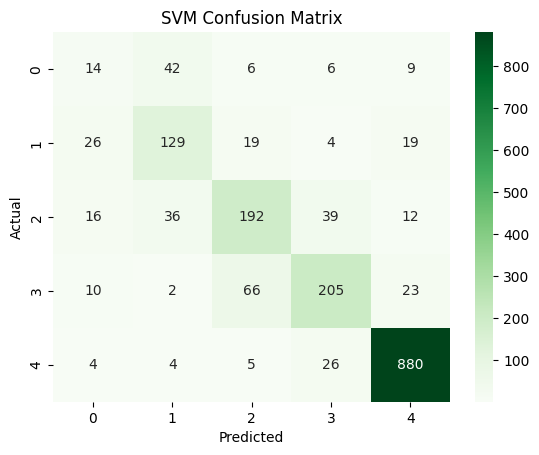

F1 Score For SVM Classifier :  78.91252834276669


Specificity for SVM :  93.68131171714829
NPV for SVM         :  94.76071938880516
FPR for SVM         :  6.318688282851717
FNR for SVM         :  20.84726867335563
ROC-AUC Score for SVM :  0.9286319137918547


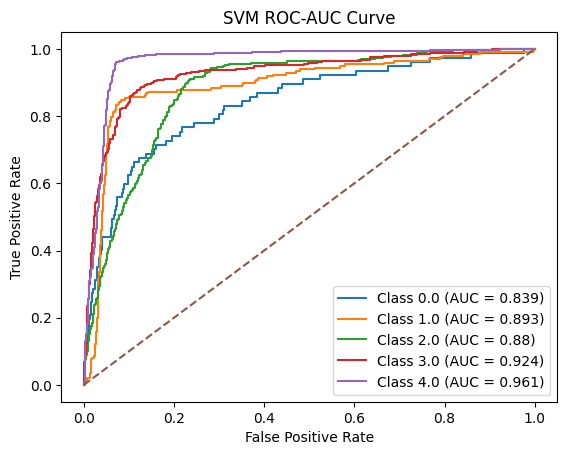

In [49]:
# Accuracy Score
ac = accuracy_score(ytest, y_pred_svm)
print("Accuracy Score : ", ac * 100)


# Classification Report
cr = classification_report(ytest, y_pred_svm)
print(cr)


# Confusion Matrix
cm = confusion_matrix(ytest, y_pred_svm)

sns.heatmap(cm, annot=True, cmap='Greens', fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()


# F1 Score
f1 = f1_score(ytest, y_pred_svm, average='weighted')

print("F1 Score For SVM Classifier : ", f1 * 100)
print("\n")


# Classes
classes = np.unique(ytest)


# Specificity, NPV, FPR, FNR

specificity_list = []
npv_list = []
fpr_list = []
fnr_list = []


for i in range(len(classes)):

    TP = cm[i, i]

    FP = cm[:, i].sum() - TP

    FN = cm[i, :].sum() - TP

    TN = cm.sum() - (TP + FP + FN)


    # Specificity
    specificity = TN / (TN + FP)

    # NPV
    npv = TN / (TN + FN)

    # False Positive Rate
    fpr = FP / (FP + TN)

    # False Negative Rate
    fnr = FN / (FN + TP)


    specificity_list.append(specificity)
    npv_list.append(npv)
    fpr_list.append(fpr)
    fnr_list.append(fnr)


# Weighted Average

weights = cm.sum(axis=1)

specificity_svm = np.average(specificity_list, weights=weights)

npv_svm = np.average(npv_list, weights=weights)

fpr_svm = np.average(fpr_list, weights=weights)

fnr_svm = np.average(fnr_list, weights=weights)


print("Specificity for SVM : ", specificity_svm * 100)
print("NPV for SVM         : ", npv_svm * 100)
print("FPR for SVM         : ", fpr_svm * 100)
print("FNR for SVM         : ", fnr_svm * 100)


# ROC-AUC

y_prob_svm = svm.predict_proba(xtest)

roc_auc_svm = roc_auc_score(
    ytest,
    y_prob_svm,
    multi_class='ovr',
    average='weighted'
)

print("ROC-AUC Score for SVM : ", roc_auc_svm)


# ROC-AUC Curve

ytest_bin = label_binarize(ytest, classes=classes)

plt.figure()

for i in range(len(classes)):

    fpr_curve, tpr_curve, threshold = roc_curve(
        ytest_bin[:, i],
        y_prob_svm[:, i]
    )

    auc_class = roc_auc_score(
        ytest_bin[:, i],
        y_prob_svm[:, i]
    )

    plt.plot(
        fpr_curve,
        tpr_curve,
        label="Class " + str(classes[i]) +
        " (AUC = " + str(round(auc_class, 3)) + ")"
    )


plt.plot([0, 1], [0, 1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("SVM ROC-AUC Curve")

plt.legend()

plt.show()

# Performing Gradient Boosting Classifier 

Training Score :  100.0
Testing Score :  92.47491638795987
Accuracy Score :  92.47491638795987
              precision    recall  f1-score   support

         0.0       0.62      0.71      0.67        77
         1.0       0.87      0.84      0.86       197
         2.0       0.89      0.92      0.90       295
         3.0       0.91      0.91      0.91       306
         4.0       0.98      0.97      0.97       919

    accuracy                           0.92      1794
   macro avg       0.86      0.87      0.86      1794
weighted avg       0.93      0.92      0.93      1794



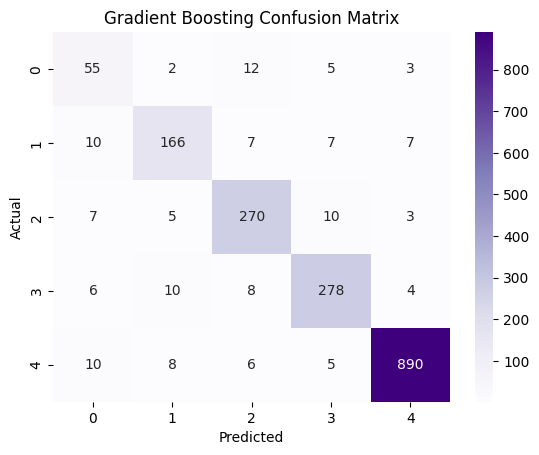

In [28]:
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

gb.fit(xtrain, ytrain)

# Training
print("Training Score : ", gb.score(xtrain, ytrain) * 100)

# Testing
print("Testing Score : ", gb.score(xtest, ytest) * 100)

#prediction
y_pred_gb = gb.predict(xtest)

# Accuracy Score
ac = accuracy_score(ytest, y_pred_gb)
print("Accuracy Score : ", ac * 100)

# Classification Report
cr = classification_report(ytest, y_pred_gb)
print(cr)

# Confusion Matrix
cm = confusion_matrix(ytest, y_pred_gb)
sns.heatmap(cm, annot=True, cmap='Purples', fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Gradient Boosting Confusion Matrix")
plt.show()

# Performing AdaBoostClassifier

Training Score :  91.47157190635451
Testing Score :  93.1438127090301
Accuracy Score :  93.1438127090301
              precision    recall  f1-score   support

         0.0       0.90      0.68      0.77        77
         1.0       0.94      0.85      0.90       197
         2.0       0.94      0.92      0.93       295
         3.0       0.89      0.92      0.90       306
         4.0       0.94      0.98      0.96       919

    accuracy                           0.93      1794
   macro avg       0.92      0.87      0.89      1794
weighted avg       0.93      0.93      0.93      1794



Text(0.5, 1.0, 'AdaBoost Confusion Matrix')

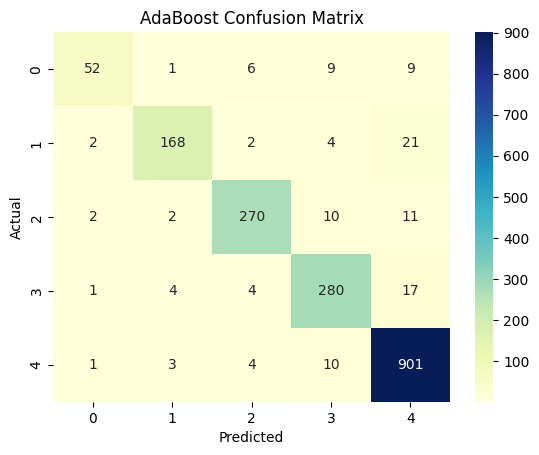

In [29]:
ada = AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

ada.fit(xtrain, ytrain)

#Training 
print("Training Score : ", ada.score(xtrain, ytrain) * 100)
#Testing 
print("Testing Score : ", ada.score(xtest, ytest) * 100)

#prediction
y_pred_ada = ada.predict(xtest)

# Accuracy Score
ac = accuracy_score(ytest, y_pred_ada)
print("Accuracy Score : ", ac * 100)

# Classification Report
cr = classification_report(ytest, y_pred_ada)   
print(cr)

# Confusion Matrix
cm = confusion_matrix(ytest, y_pred_ada)
sns.heatmap(cm, annot=True, cmap='YlGnBu', fmt='d')
plt.xlabel("Predicted")     
plt.ylabel("Actual")
plt.title("AdaBoost Confusion Matrix")

## Performing Bagging Classifier

Training Score :  100.0
Testing Score :  92.86510590858417
Accuracy Score :  92.86510590858417
              precision    recall  f1-score   support

         0.0       0.67      0.71      0.69        77
         1.0       0.86      0.86      0.86       197
         2.0       0.91      0.93      0.92       295
         3.0       0.90      0.91      0.90       306
         4.0       0.98      0.97      0.98       919

    accuracy                           0.93      1794
   macro avg       0.86      0.87      0.87      1794
weighted avg       0.93      0.93      0.93      1794



Text(0.5, 1.0, 'Bagging Classifier Confusion Matrix')

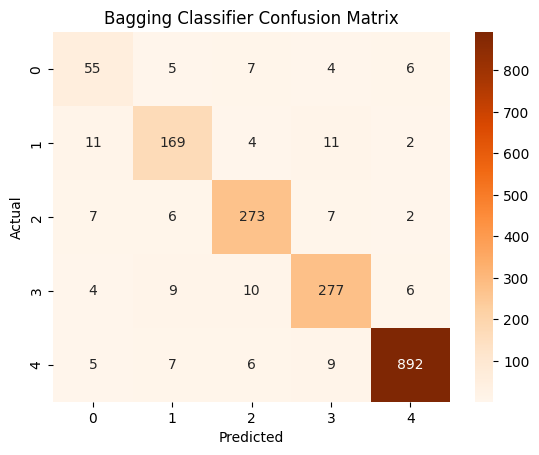

In [30]:
bc = BaggingClassifier(n_estimators=100, random_state=42)

bc.fit(xtrain, ytrain)

#training
print("Training Score : ", bc.score(xtrain, ytrain) * 100)
#testing
print("Testing Score : ", bc.score(xtest, ytest) * 100)

#prediction
y_pred_bc = bc.predict(xtest)

#accuracy score
ac = accuracy_score(ytest, y_pred_bc)
print("Accuracy Score : ", ac * 100)

#classification report
cr = classification_report(ytest, y_pred_bc)
print(cr)

#confusion matrix
cm = confusion_matrix(ytest, y_pred_bc)
sns.heatmap(cm, annot=True, cmap='Oranges', fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Bagging Classifier Confusion Matrix")

# Performing ExtraTreesClassifier

Training Score :  100.0
Testing Score :  84.00222965440356
Accuracy Score :  84.00222965440356
              precision    recall  f1-score   support

         0.0       0.74      0.40      0.52        77
         1.0       0.73      0.69      0.71       197
         2.0       0.78      0.77      0.78       295
         3.0       0.76      0.74      0.75       306
         4.0       0.91      0.97      0.94       919

    accuracy                           0.84      1794
   macro avg       0.78      0.71      0.74      1794
weighted avg       0.83      0.84      0.83      1794



Text(0.5, 1.0, 'Extra Trees Classifier Confusion Matrix')

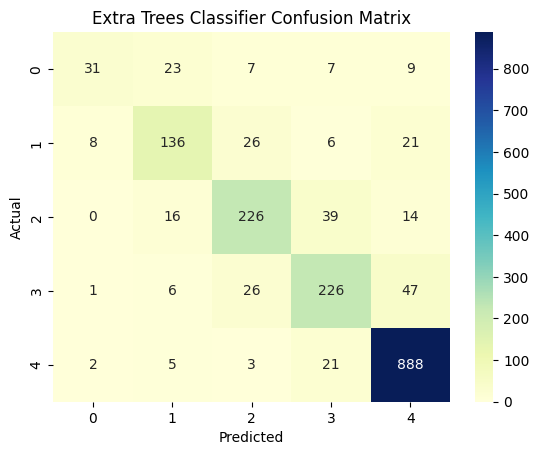

In [31]:
etc = ExtraTreesClassifier(n_estimators=100, random_state=42)

etc.fit(xtrain, ytrain)
#training
print("Training Score : ", etc.score(xtrain, ytrain) * 100)
#testing
print("Testing Score : ", etc.score(xtest, ytest) * 100)

#prediction
y_pred_etc = etc.predict(xtest)



#accuracy score
ac = accuracy_score(ytest, y_pred_etc)
print("Accuracy Score : ", ac * 100)

#classification report
cr = classification_report(ytest, y_pred_etc)   
print(cr)

#confusion matrix
cm = confusion_matrix(ytest, y_pred_etc)
sns.heatmap(cm, annot=True, cmap='YlGnBu', fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Extra Trees Classifier Confusion Matrix")

# Performing VotingClassifier

Training Score :  100.0
Testing Score :  93.19955406911929
Accuracy Score :  93.19955406911929
              precision    recall  f1-score   support

         0.0       0.80      0.69      0.74        77
         1.0       0.90      0.85      0.87       197
         2.0       0.94      0.93      0.93       295
         3.0       0.91      0.92      0.91       306
         4.0       0.95      0.98      0.97       919

    accuracy                           0.93      1794
   macro avg       0.90      0.87      0.88      1794
weighted avg       0.93      0.93      0.93      1794



Text(0.5, 1.0, 'Voting Classifier Confusion Matrix')

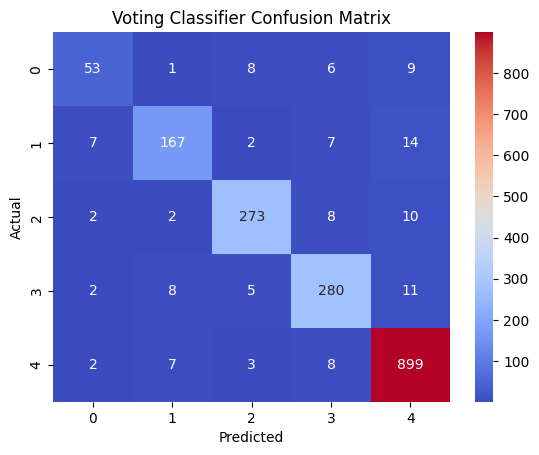

In [32]:
vt = VotingClassifier(estimators=[('rf', rf), ('dt', dt), ('xgb', xgb), ('svm', svm), ('gb', gb), ('ada', ada), ('bc', bc), ('etc', etc)], voting='hard')

vt.fit(xtrain, ytrain)

#training
print("Training Score : ", vt.score(xtrain, ytrain) * 100)
#testing
print("Testing Score : ", vt.score(xtest, ytest) * 100)

#prediction
y_pred_vt = vt.predict(xtest)

#accuracy score
ac = accuracy_score(ytest, y_pred_vt)
print("Accuracy Score : ", ac * 100)

#classification report
cr = classification_report(ytest, y_pred_vt)
print(cr)

#confusion matrix
cm = confusion_matrix(ytest, y_pred_vt)
sns.heatmap(cm, annot=True, cmap='coolwarm', fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Voting Classifier Confusion Matrix")

Training Score :  100.0
Testing Score :  84.00222965440356
Accuracy Score :  84.00222965440356
              precision    recall  f1-score   support

         0.0       0.74      0.40      0.52        77
         1.0       0.73      0.69      0.71       197
         2.0       0.78      0.77      0.78       295
         3.0       0.76      0.74      0.75       306
         4.0       0.91      0.97      0.94       919

    accuracy                           0.84      1794
   macro avg       0.78      0.71      0.74      1794
weighted avg       0.83      0.84      0.83      1794



Text(0.5, 1.0, 'Extra Trees Classifier Confusion Matrix')

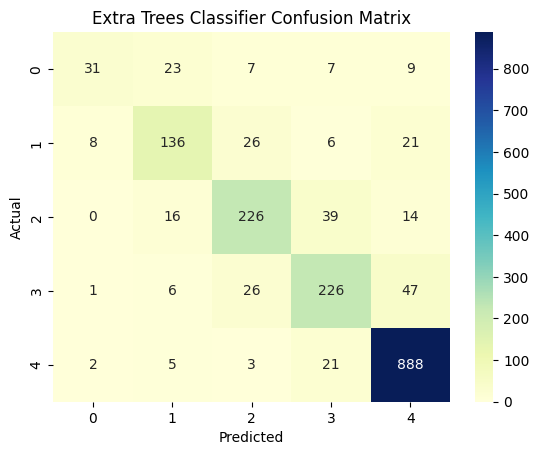

In [33]:
etc = ExtraTreesClassifier(n_estimators=100, random_state=42)

etc.fit(xtrain, ytrain)
#training
print("Training Score : ", etc.score(xtrain, ytrain) * 100)
#testing
print("Testing Score : ", etc.score(xtest, ytest) * 100)

#prediction
y_pred_etc = etc.predict(xtest)



#accuracy score
ac = accuracy_score(ytest, y_pred_etc)
print("Accuracy Score : ", ac * 100)

#classification report
cr = classification_report(ytest, y_pred_etc)   
print(cr)

#confusion matrix
cm = confusion_matrix(ytest, y_pred_etc)
sns.heatmap(cm, annot=True, cmap='YlGnBu', fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Extra Trees Classifier Confusion Matrix")

Training Score :  100.0
Testing Score :  93.25529542920847
Accuracy Score :  93.25529542920847
              precision    recall  f1-score   support

         0.0       0.82      0.69      0.75        77
         1.0       0.90      0.85      0.88       197
         2.0       0.94      0.93      0.93       295
         3.0       0.90      0.91      0.91       306
         4.0       0.96      0.98      0.97       919

    accuracy                           0.93      1794
   macro avg       0.90      0.87      0.89      1794
weighted avg       0.93      0.93      0.93      1794



Text(0.5, 1.0, 'Voting Classifier Confusion Matrix')

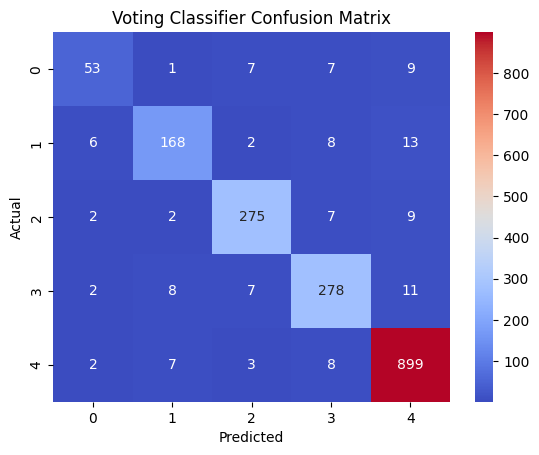

In [34]:
vt = VotingClassifier(estimators=[('rf', rf), ('dt', dt), ('xgb', xgb), ('svm', svm), ('gb', gb), ('ada', ada), ('bc', bc), ('etc', etc)], voting='hard')

vt.fit(xtrain, ytrain)

#training
print("Training Score : ", vt.score(xtrain, ytrain) * 100)
#testing
print("Testing Score : ", vt.score(xtest, ytest) * 100)

#prediction
y_pred_vt = vt.predict(xtest)

#accuracy score
ac = accuracy_score(ytest, y_pred_vt)
print("Accuracy Score : ", ac * 100)

#classification report
cr = classification_report(ytest, y_pred_vt)
print(cr)

#confusion matrix
cm = confusion_matrix(ytest, y_pred_vt)
sns.heatmap(cm, annot=True, cmap='coolwarm', fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Voting Classifier Confusion Matrix")